In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\Gradient_Boost.csv"
df = pd.read_csv(data).replace("noData",np.nan)
print(df.columns)

Index(['gmv', 'mrp', 'listing_price', 'sla_in_days', 'promise_breach',
       'listing_quality_score', 'shipment_type', 'city_tier', 'courier_name',
       'cluster', 'brand', 'order_billing_amount', 'category_id',
       'marketplace_id', 'order_sales_channel'],
      dtype='object')


In [3]:
df = df.drop(columns=['listing_quality_score', 'cluster'])
print(df.isnull().sum())

gmv                          0
mrp                          0
listing_price                0
sla_in_days                  0
promise_breach          277355
shipment_type             2681
city_tier                37804
courier_name              1905
brand                      140
order_billing_amount         0
category_id                  0
marketplace_id               0
order_sales_channel          0
dtype: int64


GBM Classifier Accuracy: 0.7602433333333334
              precision    recall  f1-score   support

           0       0.59      0.15      0.24     44612
           1       0.56      0.01      0.01     13737
           2       0.75      0.97      0.85    186069
           3       0.84      0.75      0.79     55582

    accuracy                           0.76    300000
   macro avg       0.68      0.47      0.47    300000
weighted avg       0.73      0.76      0.71    300000



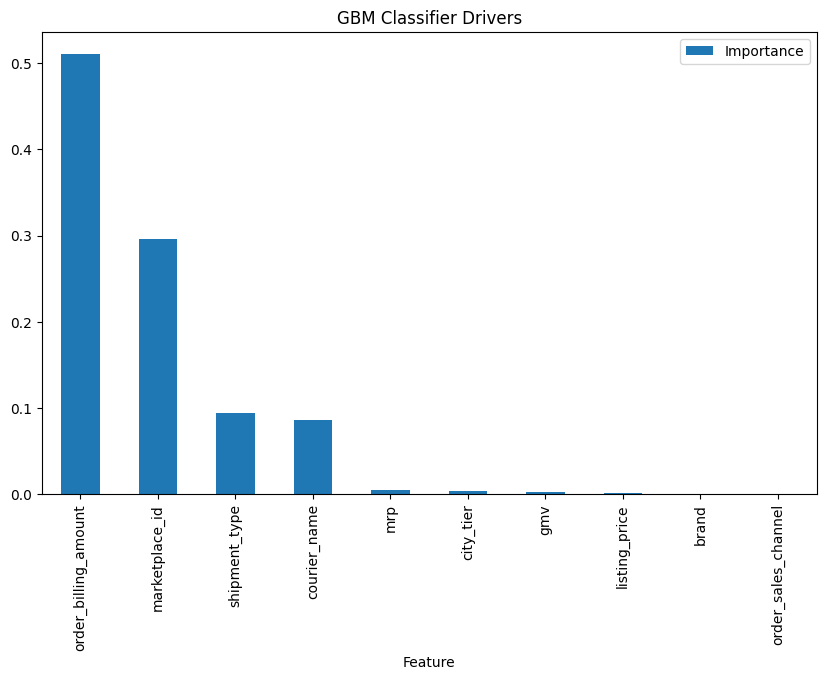

In [4]:
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = df[col].fillna("unknown")
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

X_class = df.drop(columns=['promise_breach', 'sla_in_days'])
y_class = df['promise_breach']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(n_estimators=50, learning_rate = 0.1, max_depth=5, random_state=42)
gb_clf.fit(Xc_train, yc_train)
yc_preds= gb_clf.predict(Xc_test)

print("GBM Classifier Accuracy:", accuracy_score(yc_test, yc_preds))
print(classification_report(yc_test, yc_preds))

pd.DataFrame(
    {'Feature': X_class.columns, 'Importance': gb_clf.feature_importances_}
).sort_values(by='Importance', ascending=False).head(10).plot(kind='bar', x='Feature', y='Importance', figsize=(10,6))
plt.title("GBM Classifier Drivers")
plt.show()


GBM Regressor R2: 0.6847964339502421
MAE: 1.1429168884722516
MSE: 4.181982995332768


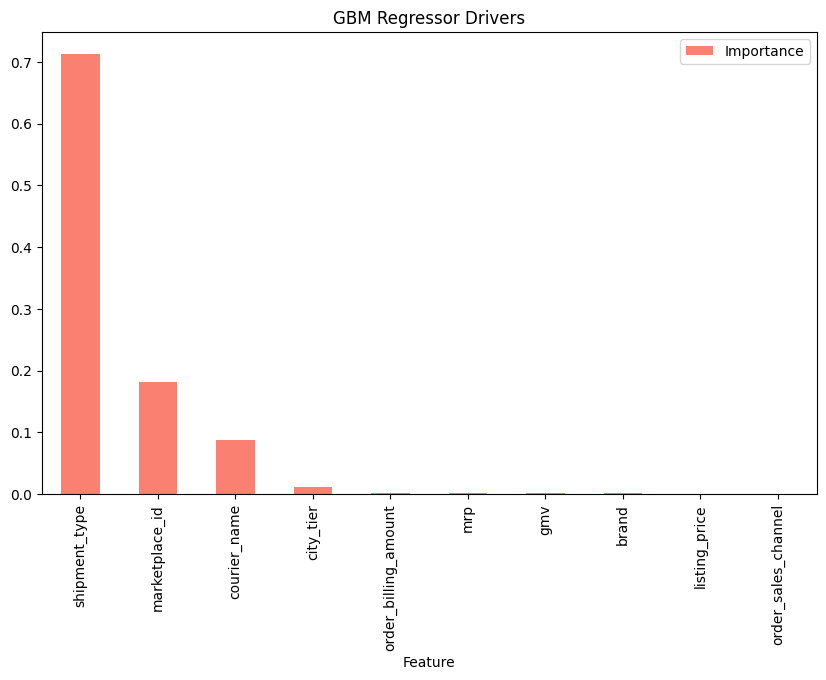

In [5]:
X_reg = df.drop(columns=['promise_breach', 'sla_in_days'])
y_reg = df['sla_in_days']
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size= 0.2, random_state=42)

gb_reg = GradientBoostingRegressor(n_estimators=50, learning_rate= 0.1, max_depth=5, random_state=42)
gb_reg.fit(Xr_train, yr_train)
yr_preds = gb_reg.predict(Xr_test)

print("GBM Regressor R2:", r2_score(yr_test, yr_preds))
print("MAE:", mean_absolute_error(yr_test, yr_preds))
print("MSE:", mean_squared_error(yr_test, yr_preds))

pd.DataFrame({'Feature':X_reg.columns, 'Importance':gb_reg.feature_importances_}).sort_values(by='Importance', ascending=False).head(10).plot(kind='bar', x='Feature', y='Importance',figsize=(10,6), color='salmon')
plt.title("GBM Regressor Drivers")
plt.show()